In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, time, timedelta
import unisacsi.Ocean as Oc
from unisacsi.Ocean import tide
import unisacsi.Meteo as Met
import unisacsi.universal_func as uf
from unisacsi.MET_model_download import download_MET_model_static_fields, download_MET_model_data
import os
from scipy import stats, signal

C:\Users\carol\miniconda3\envs\AGF211\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


#### Conductivity-Salinity conversion

In [2]:
import numpy as np

def pss78(C, t, p):
    """
    Calculate salinity (PSS-78) from conductivity (S/m),
    temperature (°C), and pressure (decibars).

    Parameters
    ----------
    C : float or array-like
        Conductivity (S/m)
    t : float or array-like
        Temperature (°C)
    p : float or array-like
        Pressure (decibars)

    Returns
    -------
    s : float or ndarray
        Salinity (PSS-78)
    """

    C = np.asarray(C)
    t = np.asarray(t)
    p = np.asarray(p)

    # Conductivity ratio
    R = C / 4.2914

    # Constants
    a0, a1, a2, a3, a4, a5 = 0.0080, -0.1692, 25.3851, 14.0941, -7.0261, 2.7081
    b0, b1, b2, b3, b4, b5 = 0.0005, -0.0056, -0.0066, -0.0375, 0.0636, -0.0144
    k = 0.0162

    c0, c1, c2, c3, c4 = 0.6766097, 2.00564e-2, 1.104259e-4, -6.9698e-7, 1.0031e-9
    d1, d2, d3, d4 = 3.426e-2, 4.464e-4, 4.215e-1, -3.107e-3
    e1, e2, e3 = 2.070e-5, -6.370e-10, 3.989e-15

    # rt35: temperature dependence
    rt35 = (((c4 * t + c3) * t + c2) * t + c1) * t + c0

    # Rp: pressure dependence
    dpol = R * (t * d4 + d3) + (d2 * t + d1) * t + 1.0
    epol = ((e3 * p + e2) * p + e1) * p
    Rp = 1.0 + epol / dpol

    # Rt: salinity dependence
    Rt = R / (Rp * rt35)
    Rt = np.sqrt(np.abs(Rt))

    # Temperature correction
    bpol = ((((Rt * b5 + b4) * Rt + b3) * Rt + b2) * Rt + b1) * Rt + b0
    dels = (t - 15.0) * bpol / (1.0 + k * (t - 15.0))

    # Final salinity
    apol = ((((Rt * a5 + a4) * Rt + a3) * Rt + a2) * Rt + a1) * Rt + a0
    s = apol + dels

    return s

### T-logger ADCP

In [3]:
file_ADCP=r'C:/Users/carol/Documents/Uni/5.Semester/Svalbard/AGF211/EKMAN/Ekman2026/AqloggerADCP.csv'
t_ADCP = pd.read_csv(
    file_ADCP,
    sep=',',          # or ',' depending on file
    skiprows=13,       # adjust if needed
    encoding='latin1',
    engine='python'
)
t_ADCP=t_ADCP.drop(columns=['UNITS', 'Raw','Latitude(°)','Dir', 'Longitude(°)','Dir.1'])
t_ADCP = t_ADCP.rename(columns={' [dd/MM/yyyy HH:mm:ss]': 'date', ' °C     ': 'Temperature [°C]'})

t_ADCP['date'] = pd.to_datetime(
    t_ADCP['date'],
    format='%d-%b-%y %H:%M:%S'
)



### T-logger Mooring

In [4]:
file_Moor=r'C:/Users/carol/Documents/Uni/5.Semester/Svalbard/AGF211/EKMAN/Ekman2026/Minilog-II-T_358946_20260321_1EkmanMooring.csv'
t_Moor=pd.read_csv(
    file_Moor,
    sep=',',          # or ',' depending on file
    skiprows=7,       # adjust if needed
    encoding='latin1',
    engine='python'
)
t_Moor = t_Moor.rename(columns={'Date(yyyy-mm-dd) Time(hh:mm:ss)': 'date'})

t_Moor['date'] = pd.to_datetime(
    t_Moor['date'],
    format='mixed')

### Seaguard 1


In [5]:
file_Seaguard=r'C:/Users/carol/Documents/Uni/5.Semester/Svalbard/AGF211/EKMAN/Ekman2026/Seaguard_1.txt'
SGuard1_data=Oc.read_Seaguard(file_Seaguard, header_len=1)
SGuard1_data = SGuard1_data.loc['2026-03-18 16:00:00':'2026-03-21 08:00:00']
SGuard1_data['v']

TIMESTAMP
2026-03-18 16:00:00   -5.425
2026-03-18 17:00:00   -2.701
2026-03-18 18:00:00    0.684
2026-03-18 19:00:00    3.508
2026-03-18 20:00:00    4.249
                       ...  
2026-03-21 04:00:00    1.985
2026-03-21 05:00:00   -0.272
2026-03-21 06:00:00   -1.712
2026-03-21 07:00:00   -0.227
2026-03-21 08:00:00    0.694
Name: v, Length: 65, dtype: float64

### Seaguard 2

In [6]:
file_Seaguard2=r"C:\Users\carol\Documents\Uni\5.Semester\Svalbard\AGF211\EKMAN\Ekman2026\5650-2803-0-2026-03-18T13-20-00.040Z.csv"
SGuard2_data = pd.read_csv(
    file_Seaguard2,
    sep=';',          # or ',' depending on file
    skiprows=15,
    parse_dates=['Record Time']# adjust if needed
    )

SGuard2_data['date'] = pd.to_datetime(
    SGuard2_data['Record Time'])

SGuard2_data.rename({'Record Time':'TIMESTAMP'}, axis=1, inplace=True)
SGuard2_data=SGuard2_data.set_index('TIMESTAMP')
SGuard2_data.sort_index(axis=0, inplace=True)
SGuard2_data = SGuard2_data.loc['2026-03-18 16:00:00':'2026-03-21 08:00:00']

SGuard2_data = SGuard2_data.loc[:, ~SGuard2_data.columns.str.contains('Status')]
#print(SGuard2_data.columns[SGuard2_data.columns.str.contains('Status')])
SGuard2_data['North[cm/s]']


TIMESTAMP
2026-03-18 21:00:00    0.855168
2026-03-18 21:20:00    2.225682
2026-03-18 21:40:00    3.442096
2026-03-18 22:00:00    2.930849
2026-03-18 22:20:00    3.216994
                         ...   
2026-03-21 04:20:00   -3.554638
2026-03-21 04:40:00   -4.133912
2026-03-21 05:00:00   -6.254115
2026-03-21 05:20:00   -5.733927
2026-03-21 05:40:00   -6.371231
Name: North[cm/s], Length: 171, dtype: float64

### Old Seabird/Seabird 2 at 8.5 m depth

In [7]:
file_SB5453=r'C:/Users/carol/Documents/Uni/5.Semester/Svalbard/AGF211/EKMAN/Ekman2026/Seabird/Seabird5453.asc'


# Find where data starts
with open(file_SB5453, 'r', encoding='latin1') as f:
    lines = f.readlines()

start_idx = None
for i, line in enumerate(lines):
    if '*END*' in line:
        start_idx = i + 3   # skip "*END*" + 2 config lines
        break

# Read data
SB5453 = pd.read_csv(
    file_SB5453,
    skiprows=start_idx+1,
    header=None,
    names=['var1', 'var2', 'var3', 'date', 'time'],
    sep=',',
    engine='python'
)

# Combine date + time
SB5453['datetime'] = pd.to_datetime(
    SB5453['date'].str.strip() + ' ' + SB5453['time'].str.strip(),
    format='%d %b %Y %H:%M:%S'
)

# Drop old columns if you want
#SB5453 = SB5453.drop(columns=['date', 'time'])
SB5453 = SB5453.rename(columns={
    'var1': 'Temperature',
    'var2': 'Conductivity',
    'var3': 'Pressure'
})
SB5453 = SB5453.set_index('datetime')
SB5453 = SB5453.loc['2026-03-18 16:00:00':'2026-03-21 08:00:00']
SB5453


,Temperature,Conductivity,Pressure,date,time
datetime,,,,,
2026-03-18 16:00:00,-1.6425,2.74024,8.847,18 Mar 2026,16:00:00
2026-03-18 16:20:00,-1.6446,2.73997,8.847,18 Mar 2026,16:20:00
2026-03-18 16:40:00,-1.6613,2.73911,8.836,18 Mar 2026,16:40:00
2026-03-18 17:00:00,-1.6496,2.73961,8.847,18 Mar 2026,17:00:00
2026-03-18 17:20:00,-1.6565,2.73883,8.836,18 Mar 2026,17:20:00
...,...,...,...,...,...
2026-03-21 06:40:00,-1.6020,2.74343,8.720,21 Mar 2026,06:40:00
2026-03-21 07:00:00,-1.5887,2.74349,8.720,21 Mar 2026,07:00:00
2026-03-21 07:20:00,-1.5642,2.74608,8.720,21 Mar 2026,07:20:00


In [8]:
SB5453['salinity']=pss78(SB5453['Conductivity'], SB5453['Temperature'], SB5453['Pressure'])
SB5453

,Temperature,Conductivity,Pressure,date,time,salinity
datetime,,,,,,
2026-03-18 16:00:00,-1.6425,2.74024,8.847,18 Mar 2026,16:00:00,34.669414
2026-03-18 16:20:00,-1.6446,2.73997,8.847,18 Mar 2026,16:20:00,34.668103
2026-03-18 16:40:00,-1.6613,2.73911,8.836,18 Mar 2026,16:40:00,34.675630
2026-03-18 17:00:00,-1.6496,2.73961,8.847,18 Mar 2026,17:00:00,34.668925
2026-03-18 17:20:00,-1.6565,2.73883,8.836,18 Mar 2026,17:20:00,34.666116
...,...,...,...,...,...,...
2026-03-21 06:40:00,-1.6020,2.74343,8.720,21 Mar 2026,06:40:00,34.666650
2026-03-21 07:00:00,-1.5887,2.74349,8.720,21 Mar 2026,07:00:00,34.651967
2026-03-21 07:20:00,-1.5642,2.74608,8.720,21 Mar 2026,07:20:00,34.659427


### Seabirds

In [9]:
SB_7626_path=r'C:/Users/carol/Documents/Uni/5.Semester/Svalbard/AGF211/EKMAN/Ekman2026/Seabird/sbe37smp-rs232_03727626_2026_03_21.cnv'
SB_7873_path=r'C:/Users/carol/Documents/Uni/5.Semester/Svalbard/AGF211/EKMAN/Ekman2026/Seabird/sbe37smp-rs232_03727873_2026_03_21.cnv'
SB_0963_path=r'C:/Users/carol/Documents/Uni/5.Semester/Svalbard/AGF211/EKMAN/Ekman2026/Seabird/SBE37SM-RS232_03710963_2026_03_21.cnv'

def read_seabird_cnv(file):
    col_names = []
    
    with open(file, 'r', encoding='latin1') as f:
        for i, line in enumerate(f):
            if line.startswith('# name'):
                col_names.append(line.split('=')[1].strip())
            if '*END*' in line:
                start_idx = i + 1
                break

    df = pd.read_csv(
        file,
        skiprows=start_idx,
        sep=r'\s+',
        header=None,
        encoding='latin1'
    )

    if len(col_names) == df.shape[1]:
        df.columns = col_names

    return df



In [10]:
SB_7626 = read_seabird_cnv(SB_7626_path) #Seabird 3 at 12 m depth
SB_7873 = read_seabird_cnv(SB_7873_path) #Seabird 1 at 2 m depth
SB_0963 = read_seabird_cnv(SB_0963_path) #Seabird 4 at 18 m depth

In [11]:


def add_datetime_column(df, time_col, start_date):
    """
    Convert elapsed seconds column into datetime.

    Parameters:
    df (pd.DataFrame): Input dataframe
    time_col (str): Column name with elapsed seconds
    start_date (datetime): Starting datetime

    Returns:
    pd.DataFrame: DataFrame with new 'datetime' column
    """
    # Ensure start_date is datetime
    start_date = pd.to_datetime(start_date)

    # Vectorized conversion
    df['datetime'] = start_date + pd.to_timedelta(df[time_col], unit='s')

    return df


In [12]:
start_date = datetime(2026, 3, 18, 13, 0)

SB_7626 = add_datetime_column(
    SB_7626,
    'timeS: Time, Elapsed [seconds]',
    start_date)

SB_7873 = add_datetime_column(
    SB_7873,
    'timeS: Time, Elapsed [seconds]',
    start_date)

SB_0963 = add_datetime_column(
    SB_0963,
    'timeS: Time, Elapsed [seconds]',
    start_date)

SB_7626 = SB_7626.set_index('datetime')
SB_7873 = SB_7873.set_index('datetime')
SB_0963 = SB_0963.set_index('datetime')
SB_7626 = SB_7626.loc['2026-03-18 16:00:00':'2026-03-21 08:00:00']
SB_7873 = SB_7873.loc['2026-03-18 16:00:00':'2026-03-21 08:00:00']
SB_0963 = SB_0963.loc['2026-03-18 16:00:00':'2026-03-21 08:00:00']
SB_0963

,"timeS: Time, Elapsed [seconds]","tv290C: Temperature [ITS-90, deg C]","sal00: Salinity, Practical [PSU]",prM: Pressure [db],"sigma-é00: Density [sigma-theta, kg/m^3]","density00: Density [density, kg/m^3]","depSM: Depth [salt water, m], lat",flag: 0.000e+00
datetime,,,,,,,,
2026-03-18 16:00:00,10800.0,-1.7726,34.7779,0.0,27.9998,1027.9998,0.0,0.0
2026-03-18 16:20:00,12000.0,-1.7698,34.7791,0.0,28.0007,1028.0007,0.0,0.0
2026-03-18 16:40:00,13200.0,-1.7649,34.7749,0.0,27.9971,1027.9971,0.0,0.0
2026-03-18 17:00:00,14400.0,-1.7597,34.7703,0.0,27.9933,1027.9933,0.0,0.0
2026-03-18 17:20:00,15600.0,-1.7597,34.7666,0.0,27.9903,1027.9903,0.0,0.0
...,...,...,...,...,...,...,...,...
2026-03-21 06:40:00,236400.0,-1.5766,34.6941,0.0,27.9259,1027.9259,0.0,0.0
2026-03-21 07:00:00,237600.0,-1.5642,34.7040,0.0,27.9335,1027.9335,0.0,0.0
2026-03-21 07:20:00,238800.0,-1.5605,34.7023,0.0,27.9320,1027.9320,0.0,0.0


### Current Plot

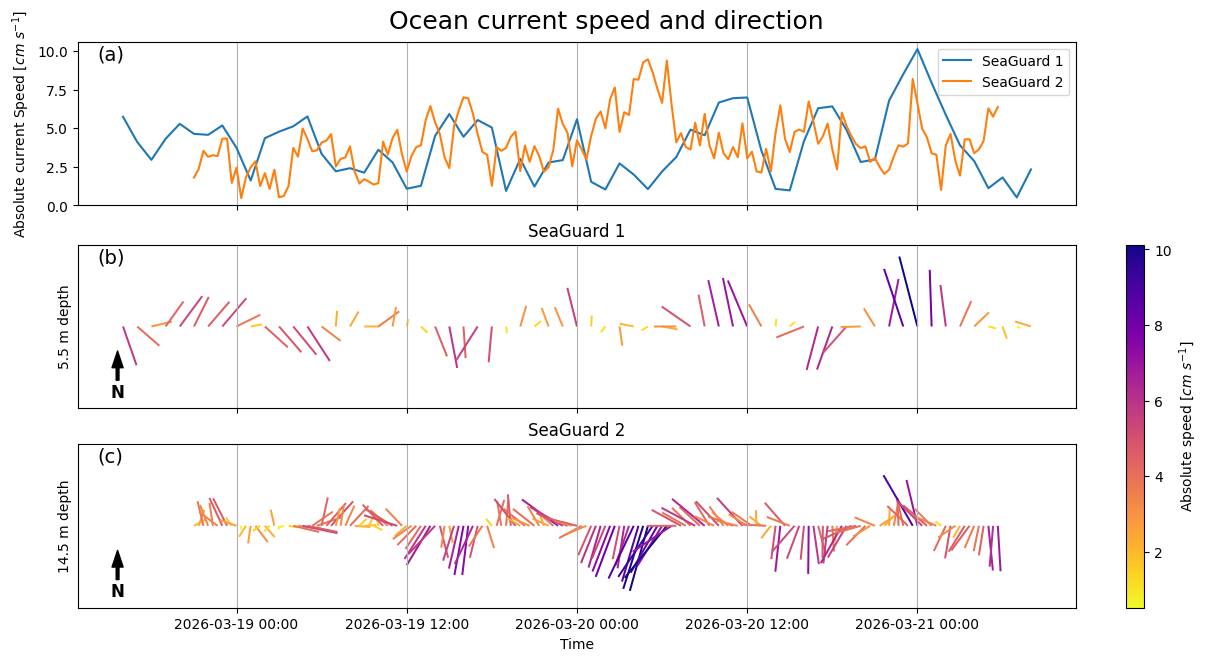

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(12,6.5), sharex=True,constrained_layout=True)
#vmin, vmax = 0, 10  # adjust based on your data
# Add panel labels
for i, ax in enumerate(axes):
    ax.text(0.02, 0.98, f'({chr(97+i)})', transform=ax.transAxes,
            fontsize=14, va='top', ha='left')
# ---------- SeaGuard 1 ----------
u1 = SGuard1_data['u']
v1 = SGuard1_data['v']
c1 = SGuard1_data['Speed_abs']  # already m/s (I assume)
# ---------- SeaGuard 2 ----------
u2 = SGuard2_data['East[cm/s]']
v2 = SGuard2_data['North[cm/s]']
c2 = np.sqrt(u2**2 + v2**2)

axes[0].plot(SGuard1_data.index, c1, label='SeaGuard 1')
axes[0].plot(SGuard2_data.index, c2, label='SeaGuard 2')
axes[0].grid(axis='x')
axes[0].legend()
axes[0].set_ylabel(r'Absolute current Speed [$cm\ s^{-1}$]')

q1 = axes[1].quiver(
    SGuard1_data.index,
    np.zeros(len(u1)),
    u1, v1, c1,
    cmap='plasma_r',
    scale=140,
    width=0.002,
    headlength=0, headwidth=0, headaxislength=0
)

axes[1].set_title('SeaGuard 1')
axes[1].set_yticks([])
axes[1].grid()
axes[1].set_ylabel('5.5 m depth')
axes[1].annotate(
    'N',
    xy=(0.04, 0.35),
    xytext=(0.04, 0.1),
    xycoords='axes fraction',
    textcoords='axes fraction',
    arrowprops=dict(facecolor='black', width=2, headwidth=8),
    ha='center',
    va='center',
    fontsize=12,
    fontweight='bold'
)

q2 = axes[2].quiver(
    SGuard2_data.index,
    np.zeros(len(u2)),
    u2, v2, c2,
    cmap='plasma_r',
    scale=140,   # smaller because now in m/s
    width=0.002,
    headlength=0, headwidth=0, headaxislength=0
)

axes[2].set_title('SeaGuard 2')
axes[2].set_yticks([])
axes[2].set_xlabel('Time')
axes[2].set_ylabel('14.5 m depth')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))



# ---------- North arrow (only once is enough) ----------
axes[2].annotate(
    'N',
    xy=(0.04, 0.35),
    xytext=(0.04, 0.1),
    xycoords='axes fraction',
    textcoords='axes fraction',
    arrowprops=dict(facecolor='black', width=2, headwidth=8),
    ha='center',
    va='center',
    fontsize=12,
    fontweight='bold'
)


# ---------- Colorbars ----------
#cbar = fig.colorbar(q1, ax=axes, location='right', shrink=0.9, pad=0.02)
#fig.colorbar(q1, ax=axes[0], label='Speed (cm/s)') 
#fig.colorbar(q2, ax=axes[1], label='Speed cm/s)')
plt.suptitle('Ocean current speed and direction',  fontsize=18)
#plt.tight_layout()
cbar = fig.colorbar(q1, ax=(axes[1],axes[2]),location='right', orientation='vertical')
cbar.set_label(r'Absolute speed [$cm\ s^{-1}$]')
plt.grid()
#plt.savefig('current_plot.png')
plt.show()



### Salinity/Seabird plots

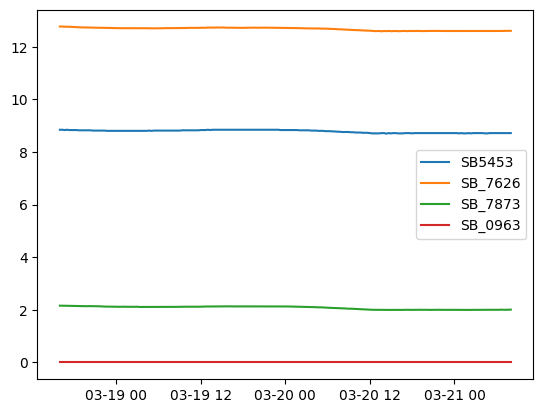

In [17]:
plt.plot(SB5453.index, SB5453['Pressure'], label='SB5453')
plt.plot(SB_7626.index,SB_7626['depSM: Depth [salt water, m], lat'], label='SB_7626')
plt.plot(SB_7873.index,SB_7873['depSM: Depth [salt water, m], lat'], label='SB_7873')
plt.plot(SB_0963.index,SB_0963['depSM: Depth [salt water, m], lat'], label='SB_0963')
plt.legend()

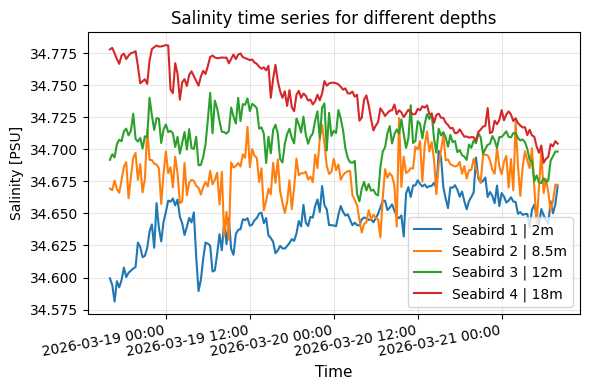

In [88]:
#plt.plot(t_ADCP['date'], t_ADCP['Temperature [°C]'], label='ADCP temperature logger')
#plt.plot(t_Moor['date'], t_Moor['Temperature (°C)'], label='Mooring temperature logger')
#plt.plot(SGuard1_data['date'], SGuard1_data['Temperature'], label='Seaguard 1')
fig, ax = plt.subplots(figsize=[6, 4])
ax.plot(SB_7873.index, SB_7873['sal00: Salinity, Practical [PSU]'], label='Seabird 1 | 2m')
ax.plot(SB5453.index, SB5453['salinity'], label='Seabird 2 | 8.5m')
ax.plot(SB_7626.index, SB_7626['sal00: Salinity, Practical [PSU]'], label='Seabird 3 | 12m')
ax.plot(SB_0963.index, SB_0963['sal00: Salinity, Practical [PSU]'], label='Seabird 4 | 18m')
ax.legend(fontsize=11)
ax.set_ylabel('Salinity [PSU]')
ax.set_xlabel('Time', fontsize=11)
ax.set_title('Salinity time series for different depths')
ax.grid(alpha=0.3)
#plt.savefig('salinity_time.png')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.setp(ax.get_xticklabels(), rotation=10, ha='right')
plt.tight_layout()
plt.savefig('salinity_time.png', dpi=300)
plt.show()

In [19]:
x=[SB_7626['sal00: Salinity, Practical [PSU]'].mean(),SB_7873['sal00: Salinity, Practical [PSU]'].mean(),SB_0963['sal00: Salinity, Practical [PSU]'].mean(),SB5453['salinity'].mean()]
y=[SB_7626['depSM: Depth [salt water, m], lat'].mean(),SB_7873['depSM: Depth [salt water, m], lat'].mean(),18,SB5453['Pressure'].mean()]
slope, intercept, r, p, std_err = stats.linregress(x, y) 
def linreg(x):
  return slope * x + intercept
salinmodel = list(map(linreg, x)) 

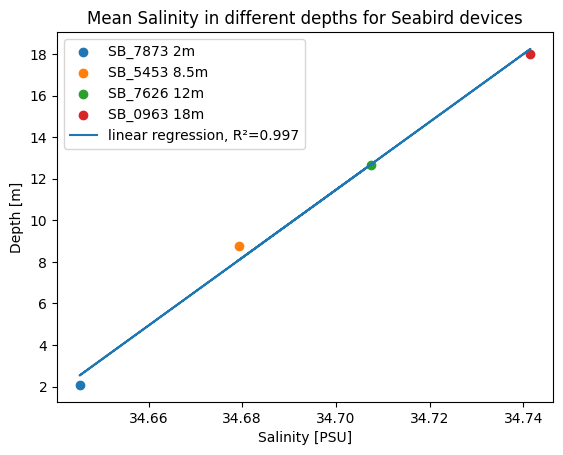

In [20]:
plt.scatter(SB_7873['sal00: Salinity, Practical [PSU]'].mean(),SB_7873['depSM: Depth [salt water, m], lat'].mean(), label='SB_7873 2m')
plt.scatter(SB5453['salinity'].mean(),SB5453['Pressure'].mean(), label='SB_5453 8.5m')
plt.scatter(SB_7626['sal00: Salinity, Practical [PSU]'].mean(),SB_7626['depSM: Depth [salt water, m], lat'].mean(), label='SB_7626 12m')
#plt.scatter(SB_0963['sal00: Salinity, Practical [PSU]'].mean(),SB_0963['depSM: Depth [salt water, m], lat'].mean(), label='SB_0963')
plt.scatter(SB_0963['sal00: Salinity, Practical [PSU]'].mean(),18, label='SB_0963 18m')
plt.plot(x, salinmodel, label=f'linear regression, R²={round(r, 3)}')
plt.xlabel('Salinity [PSU]')
plt.ylabel('Depth [m]')
plt.title('Mean Salinity in different depths for Seabird devices')
plt.legend()
#plt.savefig('salinity_depth.png')



#### T-S-plot 

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

<Figure size 640x480 with 0 Axes>

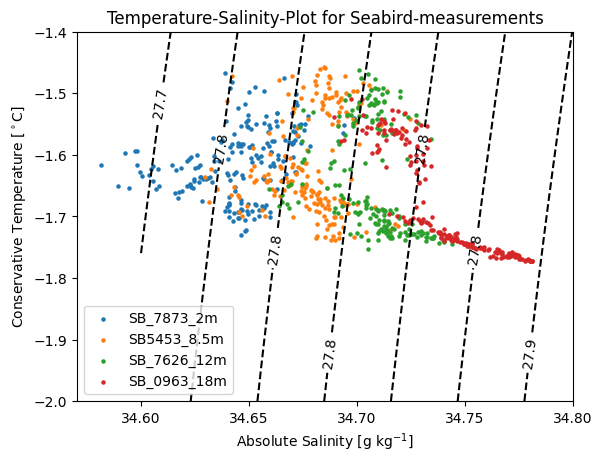

In [21]:

plt.figure()
Oc.create_empty_ts(T_extent=[-2., -1.4],S_extent=[34.6,34.8])
S_SB_7873 = plt.scatter(SB_7873['sal00: Salinity, Practical [PSU]'],SB_7873['tv290C: Temperature [ITS-90, deg C]'],
                s=5, cmap='cmo.matter',
                   vmin=5.8,vmax=7.8, label='SB_7873_2m')
S_SB_5453 = plt.scatter(SB5453['salinity'],SB5453['Temperature'],
                s=5, cmap='cmo.matter',
                 vmin=5.8,vmax=7.8, label='SB5453_8.5m')
S_SB_7626 = plt.scatter(SB_7626['sal00: Salinity, Practical [PSU]'],SB_7626['tv290C: Temperature [ITS-90, deg C]'],
                s=5, cmap='cmo.matter',
                   vmin=5.8,vmax=7.8, label='SB_7626_12m')
S_SB_0963 = plt.scatter(SB_0963['sal00: Salinity, Practical [PSU]'],SB_0963['tv290C: Temperature [ITS-90, deg C]'],
                s=5, cmap='cmo.matter',
                   vmin=5.8,vmax=7.8, label='SB_0963_18m')
plt.title('Temperature-Salinity-Plot for Seabird-measurements')
plt.legend()
plt.tight_layout
#plt.savefig('salinity_temp_complete.png')

#plt.colorbar(S_SB_7626,label='Oxygen (mL/L)')


### Oxygen

In [22]:
SGuard2_data.columns

Index(['Record Number', 'Abs Speed[cm/s]', 'Direction[Deg.M]', 'North[cm/s]',
       'East[cm/s]', 'Heading[Deg.M]', 'Tilt X[Deg]', 'Tilt Y[Deg]',
       'SP Std[cm/s]', 'Strength[dB]', 'Ping Count', 'Abs Tilt[Deg]',
       'Max Tilt[Deg]', 'Std Tilt[Deg]', 'O2Concentration[uM]',
       'O2Content[mg/l]', 'AirSaturation[%]', 'Temperature[Deg.C]',
       'Pressure[kPa]', 'Temperature[DegC]', 'Input Voltage[V]',
       'Memory Used[Bytes]', 'date'],
      dtype='str')

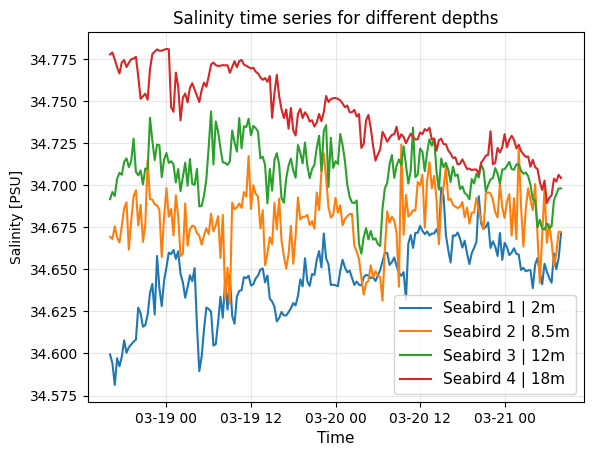

In [56]:
plt.plot(SB_7873.index, SB_7873['sal00: Salinity, Practical [PSU]'], label='Seabird 1 | 2m')
plt.plot(SB5453.index, SB5453['salinity'], label='Seabird 2 | 8.5m')
plt.plot(SB_7626.index, SB_7626['sal00: Salinity, Practical [PSU]'], label='Seabird 3 | 12m')
plt.plot(SB_0963.index, SB_0963['sal00: Salinity, Practical [PSU]'], label='Seabird 4 | 18m')
plt.legend(fontsize=11)
plt.ylabel('Salinity [PSU]')
plt.xlabel('Time', fontsize=11)
plt.title('Salinity time series for different depths')
plt.grid(alpha=0.3)
#plt.savefig('salinity_time.png')

## Tide analysis

### Tidal Constituents

In [1]:
#tide??

In [27]:
td = tide(
    t=SGuard1_data.index,
    v =SGuard1_data['v'],
    u = SGuard1_data['u'],
    lat=78.0
)
#print("Constituents:",td.constituents)
td.constituents

solve: matrix prep ... solution ... done.


,amp_major,amp_major_ci,amp_minor,amp_minor_ci,inclination [deg],inclination_ci [deg],phase [deg],phase_ci [deg],snr,rotation,PE [%],percent_variability
M2,4.620003,0.579702,-0.416704,0.517445,93.205332,6.573194,280.396139,7.193196,136.905103,CCW,85.327373,0.857967
M6,0.937068,0.449129,-0.038956,0.459114,133.521195,28.227790,232.183535,27.437753,8.191767,CCW,3.488003,0.035296
K1,1.181779,0.610816,-0.021759,0.535496,56.061222,25.760684,140.215133,29.894735,8.133653,CCW,5.539934,0.056138
M3,0.664848,0.493234,0.049974,0.192369,21.147822,16.949099,332.280009,42.885639,6.092615,CW,1.762692,0.017768
2MK5,0.586725,0.485051,-0.008684,0.482349,20.131679,47.240003,50.554424,47.260778,2.826772,CCW,1.365367,0.013837
M8,0.479112,0.556696,-0.204013,0.255921,166.426357,50.951464,37.079256,82.867056,2.774926,CCW,1.075290,0.009227
3MK7,0.323165,0.488392,0.203881,0.299684,164.549516,126.473845,124.072768,153.888181,1.708262,CW,0.578957,0.004198
M4,0.372210,0.534963,-0.280958,0.509028,3.731706,232.454742,104.710508,235.705995,1.532128,CCW,0.862382,0.005569


In [28]:
#td.calc_spectrum(bandwidth=8)
#there are different ways to plot the spectrum:
# by excluding constituents
#print("Plotting spectrum excluding some constituents")
#td.plot_spectrum(exclude_constituents=['S2','N2','K2', 'O1', 'NU2', 'SO3', 'UPS1', 'MK3', 'RHO1', 'MU2', 'THE1', 'MKS2', 'M3', 'BET1', 'SSA', 'LDA2', 'MO3', 'CHI1', 'NO1', 'SIG1', 'ETA2', '2Q1', 'PHI1', '2SM6', 'Q1', 'J1', 'SO1', 'P1', 'OQ2', 'TAU1', 'M4', 'SN4', 'OO1', 'SK3', 'MM', '2MS6', 'ALP1', 'L2', 'MN4', '2SK5', '2MK6', 'MSF', '2MK5', 'MSK6', 'MS4', 'MF', 'MSN2', 'EPS2', '2N2', '3MK7', '2MN6', 'MSM', 'MK4', 'S4', 'M8', 'SK4', 'M6'])
#plt.show()
# or by selecting constituents
print("Plotting spectrum with selected constituents")
#td.plot_spectrum(constituents=['M2'])
#plt.show()
# or by plotting all consituents
print("Plotting spectrum with all constituents")
#td.plot_spectrum()

Plotting spectrum with selected constituents
Plotting spectrum with all constituents


Only use M2 constit. to calc reconstructed tide \
topography as controlling factor\
external factor=warm inflow\
compare tides with microcat -> warm intrusion same time as westward turn\
compare with topography, weather groups, ocean group.CTD \
utide: signal to noise ratio, what components we use for tidal analysis (minimum for reconstruction is 2 by default)\
try different constituents \
tide object.reconstruct \

prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.


(<Figure size 1000x333.333 with 1 Axes>, [<Axes: >])

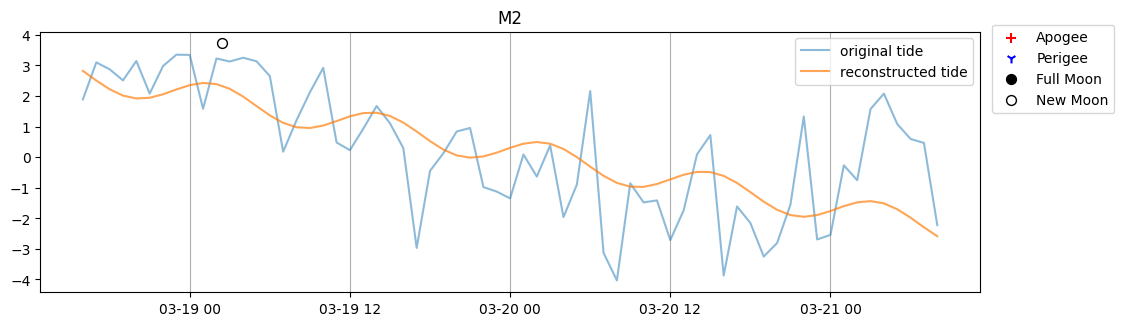

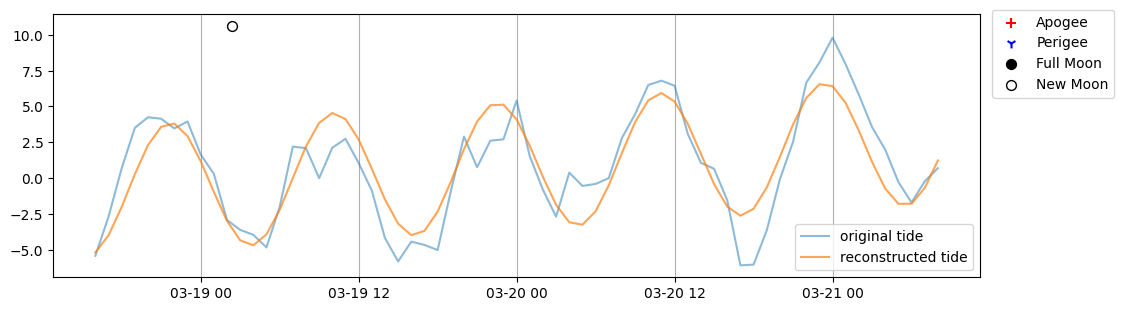

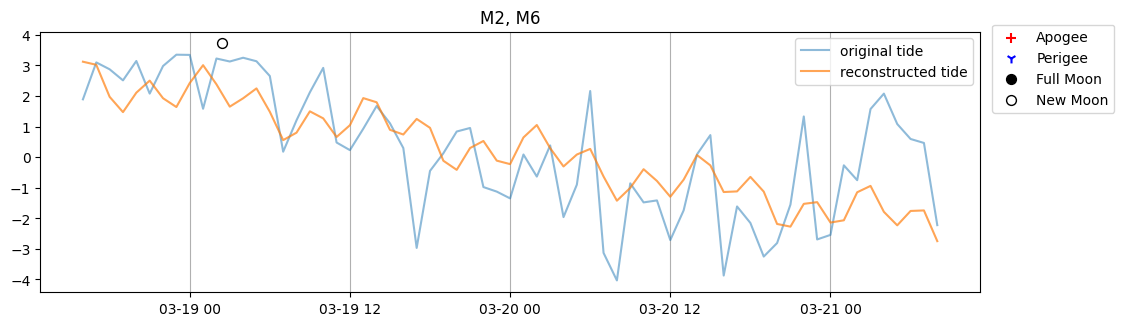

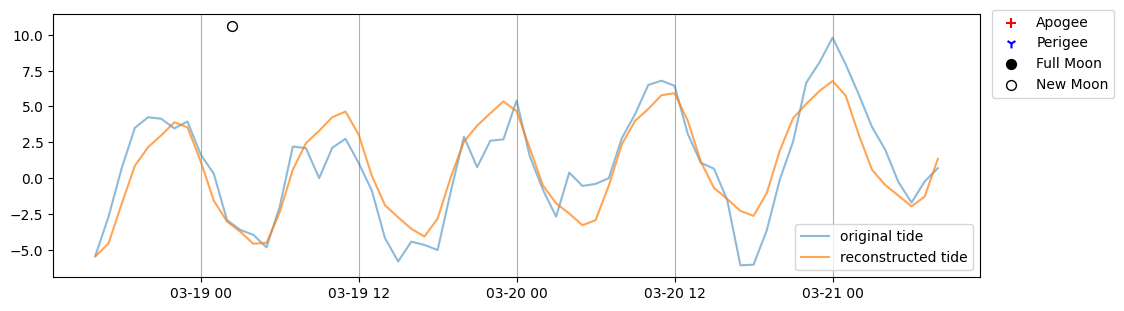

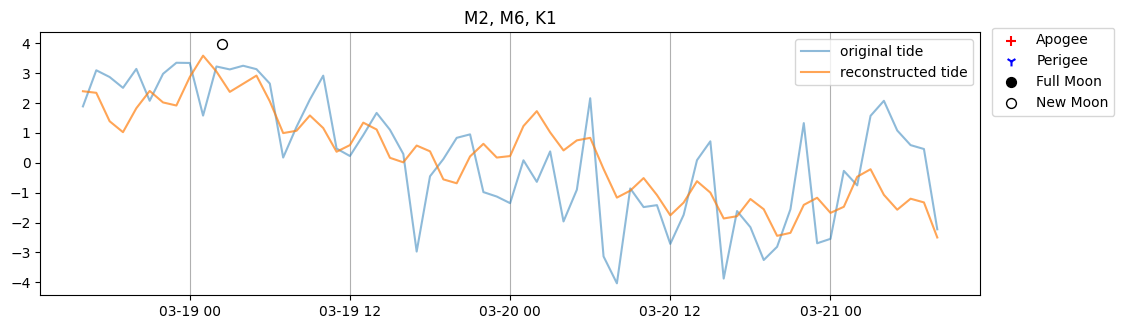

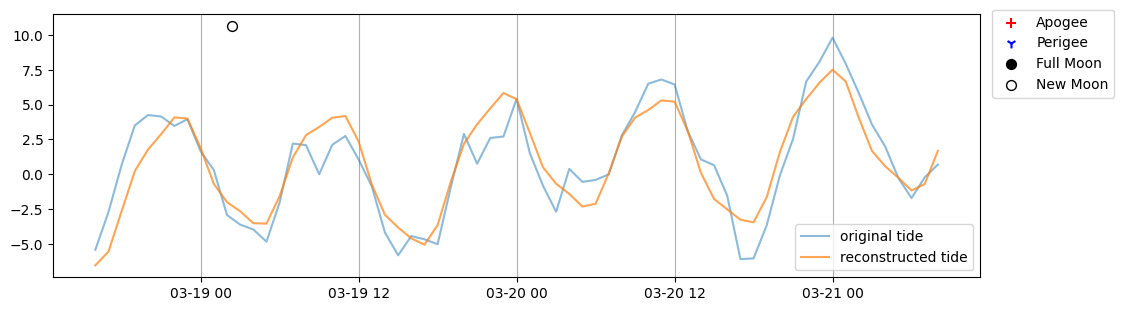

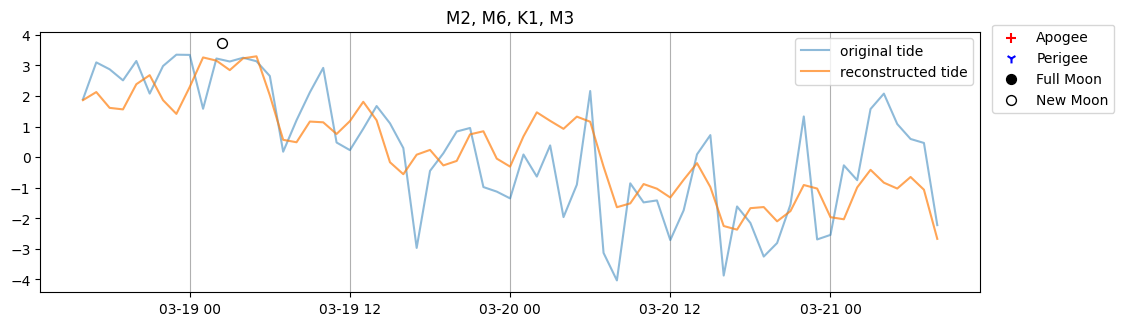

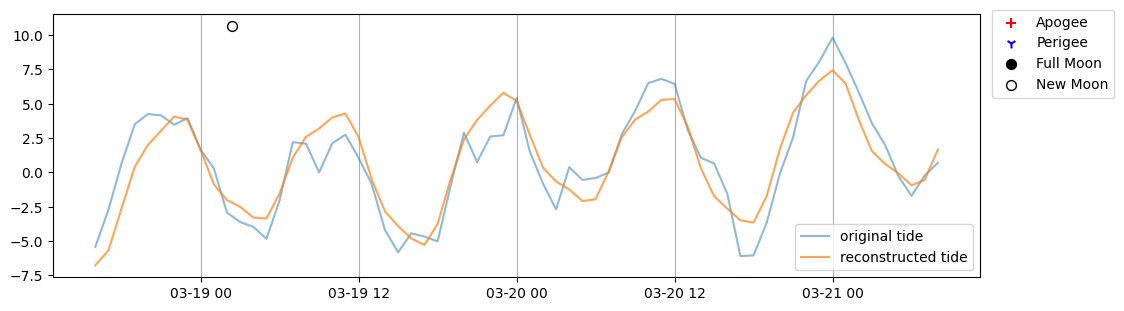

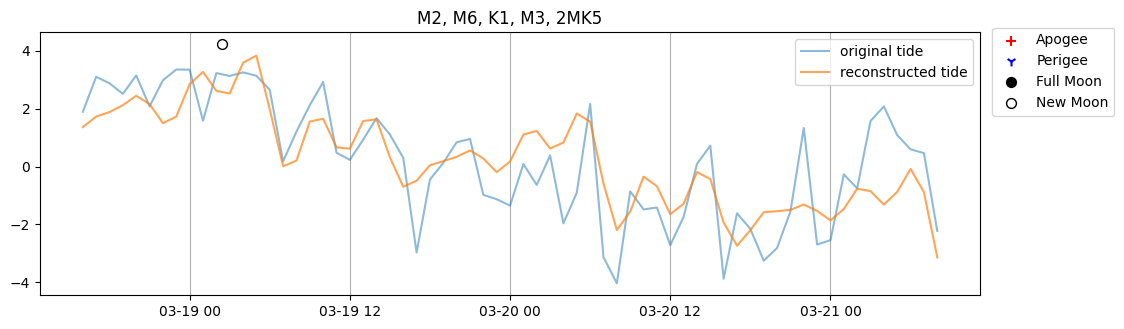

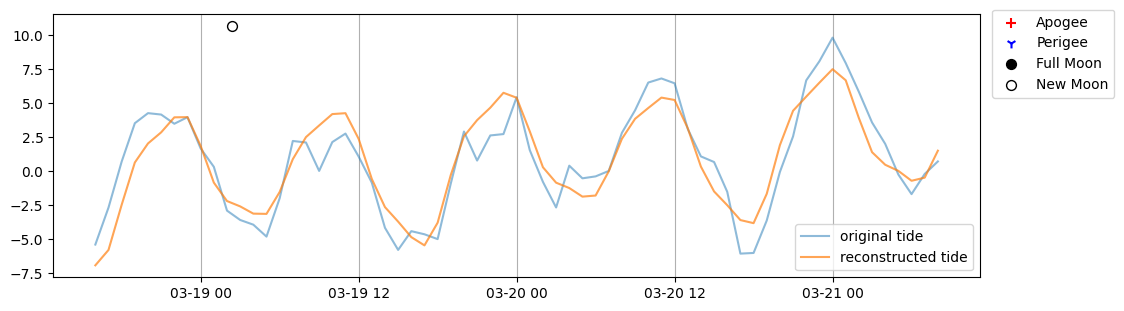

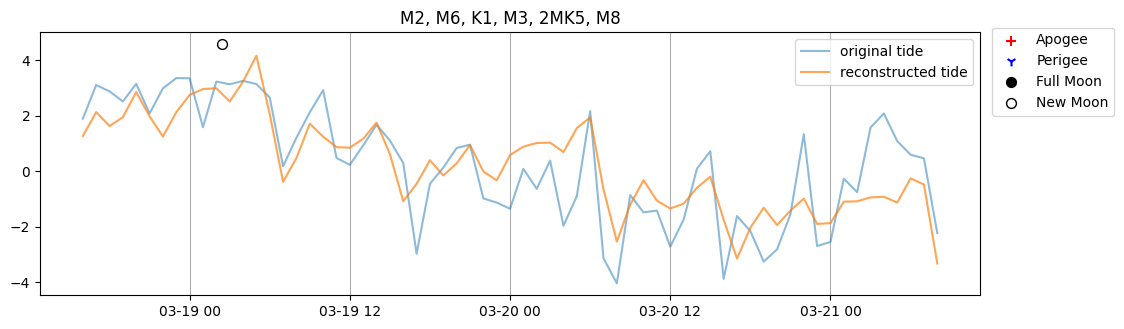

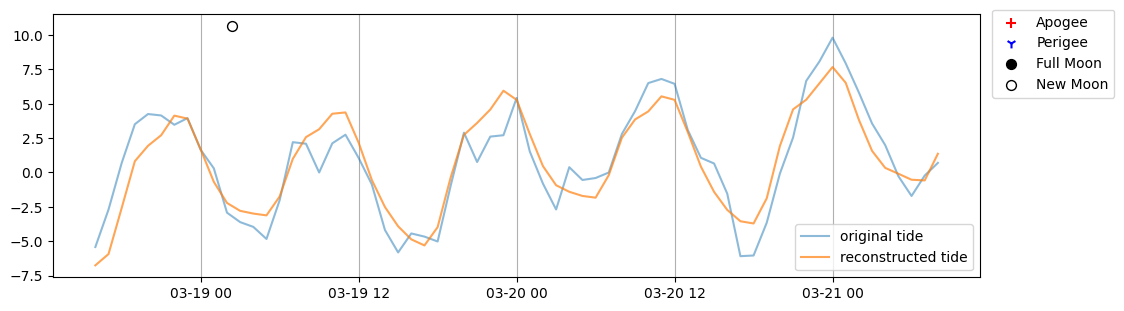

In [29]:
td.reconstruct(constituents=['M2']) # reconstructs the tide using only the selected constituents, to include all constituents leave the argument out
Oc.plot_tidal_time_series(td.u,td.t, td.recon.u,label="original tide",transparent_labels="reconstructed tide")
plt.title('M2')
Oc.plot_tidal_time_series(td.v,td.t, td.recon.v,label="original tide",transparent_labels="reconstructed tide")
td.reconstruct(constituents=['M2', 'M6']) # reconstructs the tide using only the selected constituents, to include all constituents leave the argument out
Oc.plot_tidal_time_series(td.u,td.t, td.recon.u,label="original tide",transparent_labels="reconstructed tide")
plt.title('M2, M6')
Oc.plot_tidal_time_series(td.v,td.t, td.recon.v,label="original tide",transparent_labels="reconstructed tide")
td.reconstruct(constituents=['M2', 'M6', 'K1']) # reconstructs the tide using only the selected constituents, to include all constituents leave the argument out
Oc.plot_tidal_time_series(td.u,td.t, td.recon.u,label="original tide",transparent_labels="reconstructed tide")
plt.title('M2, M6, K1')
Oc.plot_tidal_time_series(td.v,td.t, td.recon.v,label="original tide",transparent_labels="reconstructed tide")
td.reconstruct(constituents=['M2', 'M6', 'K1', 'M3']) # reconstructs the tide using only the selected constituents, to include all constituents leave the argument out
Oc.plot_tidal_time_series(td.u,td.t, td.recon.u,label="original tide",transparent_labels="reconstructed tide")
plt.title('M2, M6, K1, M3')
Oc.plot_tidal_time_series(td.v,td.t, td.recon.v,label="original tide",transparent_labels="reconstructed tide")
td.reconstruct(constituents=['M2', 'M6', 'K1', 'M3','2MK5']) # reconstructs the tide using only the selected constituents, to include all constituents leave the argument out
Oc.plot_tidal_time_series(td.u,td.t, td.recon.u,label="original tide",transparent_labels="reconstructed tide")
plt.title('M2, M6, K1, M3, 2MK5')
Oc.plot_tidal_time_series(td.v,td.t, td.recon.v,label="original tide",transparent_labels="reconstructed tide")
td.reconstruct(constituents=['M2', 'M6', 'K1', 'M3','2MK5','M8']) # reconstructs the tide using only the selected constituents, to include all constituents leave the argument out
Oc.plot_tidal_time_series(td.u,td.t, td.recon.u,label="original tide",transparent_labels="reconstructed tide")
plt.title('M2, M6, K1, M3, 2MK5, M8')
Oc.plot_tidal_time_series(td.v,td.t, td.recon.v,label="original tide",transparent_labels="reconstructed tide")

In [30]:
td2 = tide(
    t=SGuard2_data.index,
    v=SGuard2_data['North[cm/s]'],
    u=SGuard2_data['East[cm/s]'],
    lat=78.0
)
td2.constituents

solve: matrix prep ... solution ... done.


,amp_major,amp_major_ci,amp_minor,amp_minor_ci,inclination [deg],inclination_ci [deg],phase [deg],phase_ci [deg],snr,rotation,PE [%],percent_variability
M2,3.957844,0.095333,0.674079,0.399420,96.777828,5.884526,257.632381,1.751267,367.220570,CW,81.784480,0.822695
M6,1.414435,0.317442,-0.025297,0.403674,115.572758,16.503078,186.655064,12.754260,29.152160,CCW,10.154074,0.105072
M4,0.815681,0.301383,-0.206086,0.290866,136.340535,22.441801,333.014737,23.547147,15.499282,CCW,3.591285,0.034943
M8,0.457153,0.249795,-0.328359,0.421329,71.139420,118.730191,234.706715,101.694337,5.072830,CCW,1.607432,0.010976
2MK5,0.443424,0.249247,0.142850,0.373113,92.704380,55.197615,288.547903,39.808548,4.141037,CW,1.101177,0.010327
3MK7,0.295078,0.301025,-0.184335,0.350409,55.662481,126.311638,92.235819,118.711883,2.179120,CCW,0.614190,0.004573
M3,0.269994,0.662897,-0.072813,0.411314,93.524326,102.374093,65.117554,154.342174,0.493594,CCW,0.396765,0.003829
K1,0.380033,0.999244,-0.059246,0.882908,49.916123,134.986065,108.817979,159.265598,0.319631,CCW,0.750598,0.007585


In [31]:
#td2.calc_spectrum(bandwidth=8)
#there are different ways to plot the spectrum:
# by excluding constituents
#print("Plotting spectrum excluding some constituents")
#td2.plot_spectrum(exclude_constituents=['S2','N2','K2', 'O1', 'NU2', 'SO3', 'UPS1', 'MK3', 'RHO1', 'MU2', 'THE1', 'MKS2', 'M3', 'BET1', 'SSA', 'LDA2', 'MO3', 'CHI1', 'NO1', 'SIG1', 'ETA2', '2Q1', 'PHI1', '2SM6', 'Q1', 'J1', 'SO1', 'P1', 'OQ2', 'TAU1', 'M4', 'SN4', 'OO1', 'SK3', 'MM', '2MS6', 'ALP1', 'L2', 'MN4', '2SK5', '2MK6', 'MSF', '2MK5', 'MSK6', 'MS4', 'MF', 'MSN2', 'EPS2', '2N2', '3MK7', '2MN6', 'MSM', 'MK4', 'S4', 'M8', 'SK4', 'M6'])
#plt.show()
# or by selecting constituents
#print("Plotting spectrum with selected constituents")
#td2.plot_spectrum(constituents=['S2','K1', 'O1'])
#plt.show()
# or by plotting all consituents
#print("Plotting spectrum with all constituents")
#td2.plot_spectrum()
#Oc.tide??

prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.


(<Figure size 1000x333.333 with 1 Axes>, [<Axes: >])

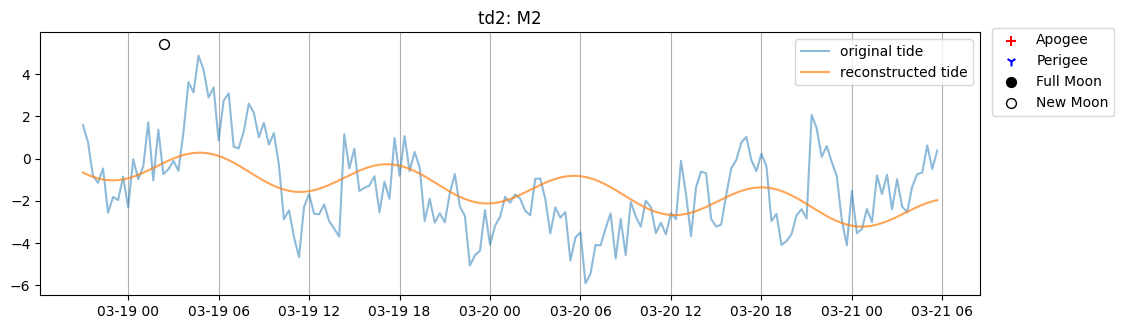

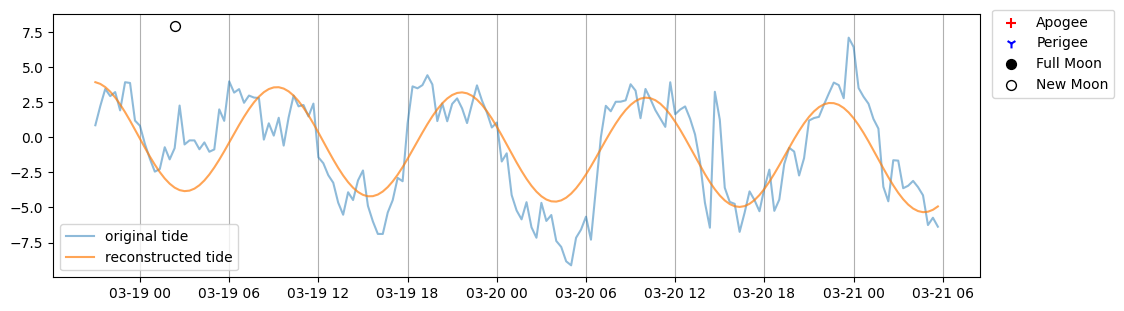

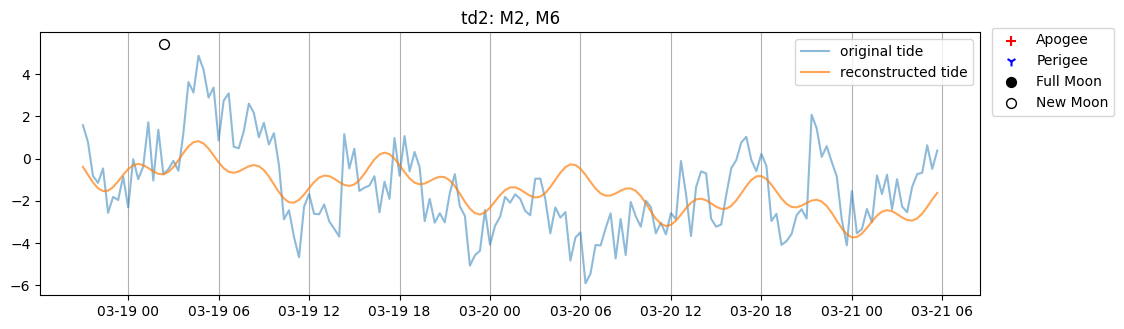

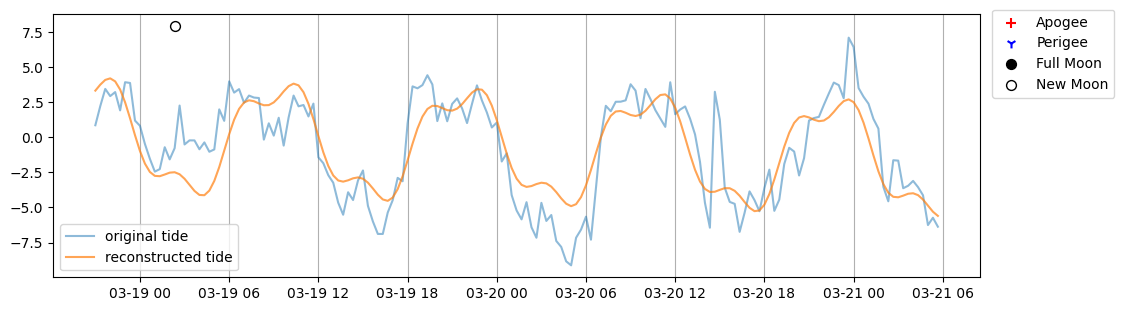

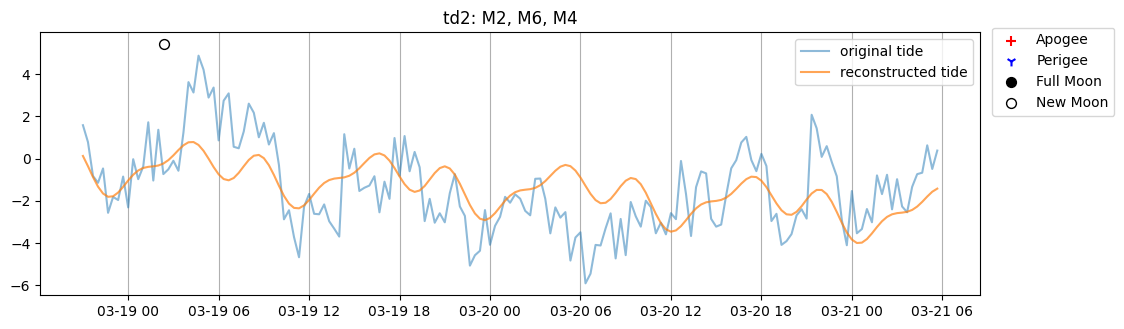

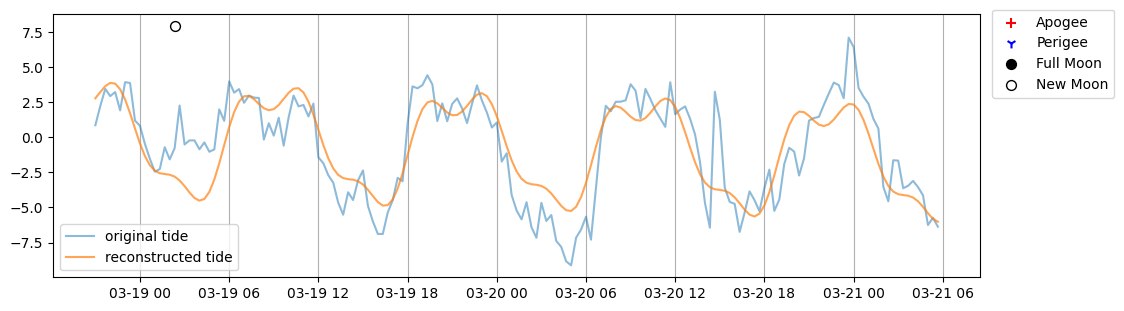

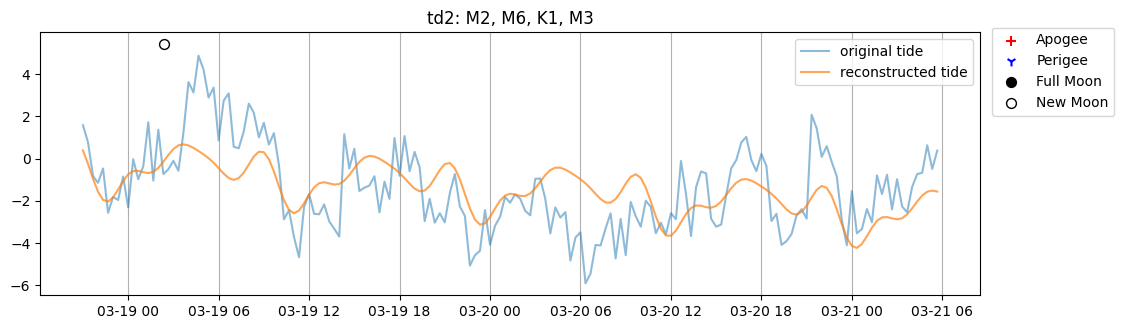

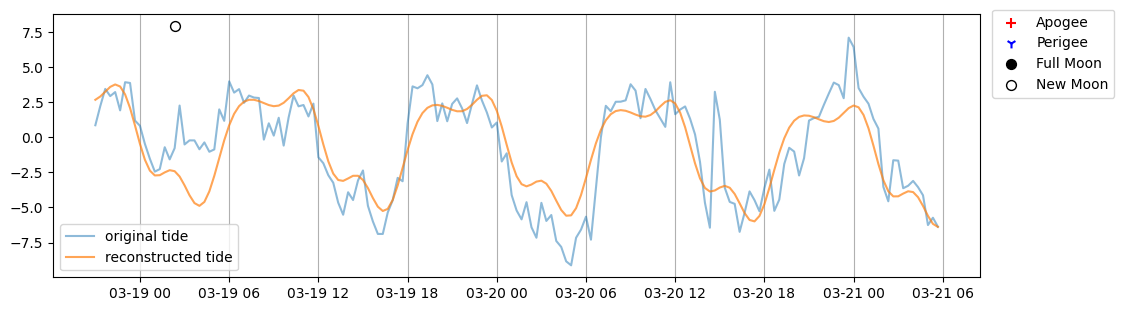

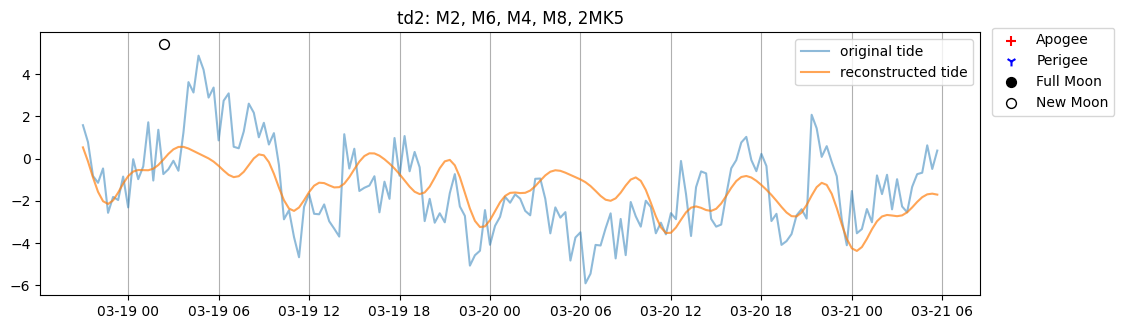

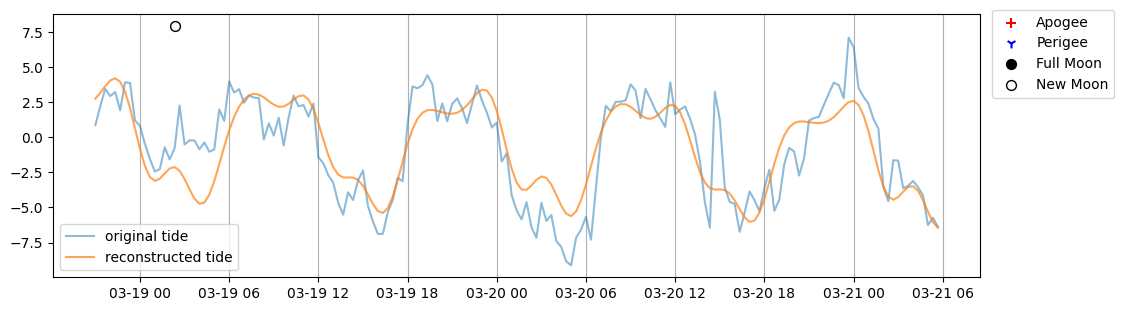

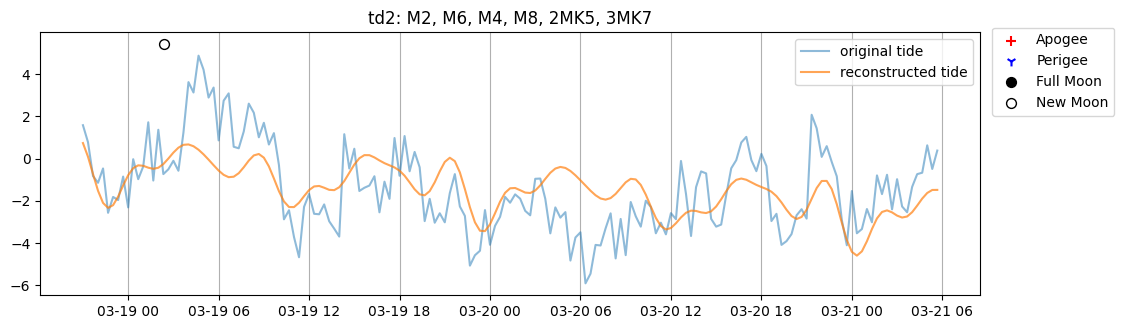

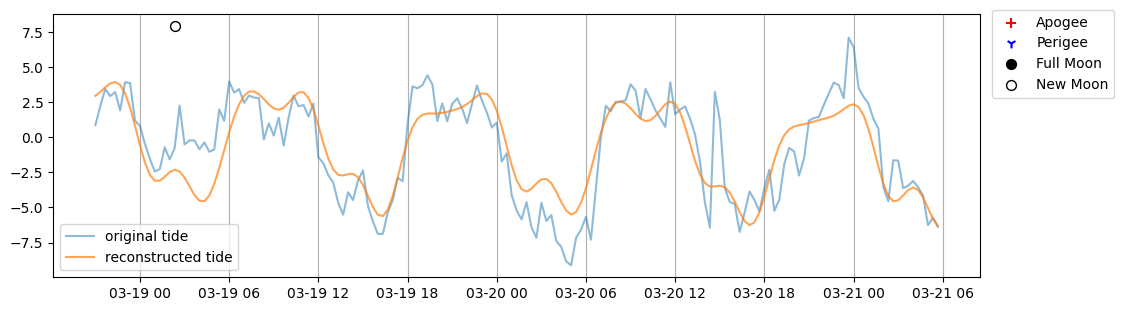

In [32]:
td2.reconstruct(constituents=['M2']) # reconstructs the tide using only the selected constituents, to include all constituents leave the argument out
Oc.plot_tidal_time_series(td2.u,td2.t, td2.recon.u,label="original tide",transparent_labels="reconstructed tide")
plt.title('td2: M2')
Oc.plot_tidal_time_series(td2.v,td2.t, td2.recon.v,label="original tide",transparent_labels="reconstructed tide")
td2.reconstruct(constituents=['M2', 'M6']) # reconstructs the tide using only the selected constituents, to include all constituents leave the argument out
Oc.plot_tidal_time_series(td2.u,td2.t, td2.recon.u,label="original tide",transparent_labels="reconstructed tide")
plt.title('td2: M2, M6')
Oc.plot_tidal_time_series(td2.v,td2.t, td2.recon.v,label="original tide",transparent_labels="reconstructed tide")
td2.reconstruct(constituents=['M2', 'M6', 'M4']) # reconstructs the tide using only the selected constituents, to include all constituents leave the argument out
Oc.plot_tidal_time_series(td2.u,td2.t, td2.recon.u,label="original tide",transparent_labels="reconstructed tide")
plt.title('td2: M2, M6, M4')
Oc.plot_tidal_time_series(td2.v,td2.t, td2.recon.v,label="original tide",transparent_labels="reconstructed tide")
td2.reconstruct(constituents=['M2', 'M6', 'M4', 'M8']) # reconstructs the tide using only the selected constituents, to include all constituents leave the argument out
Oc.plot_tidal_time_series(td2.u,td2.t, td2.recon.u,label="original tide",transparent_labels="reconstructed tide")
plt.title('td2: M2, M6, K1, M3')
Oc.plot_tidal_time_series(td2.v,td2.t, td2.recon.v,label="original tide",transparent_labels="reconstructed tide")
td2.reconstruct(constituents=['M2', 'M6', 'M4', 'M8','2MK5']) # reconstructs the tide using only the selected constituents, to include all constituents leave the argument out
Oc.plot_tidal_time_series(td2.u,td2.t, td2.recon.u,label="original tide",transparent_labels="reconstructed tide")
plt.title('td2: M2, M6, M4, M8, 2MK5')
Oc.plot_tidal_time_series(td2.v,td2.t, td2.recon.v,label="original tide",transparent_labels="reconstructed tide")
td2.reconstruct(constituents=['M2', 'M6', 'M4', 'M8','2MK5', '3MK7']) # reconstructs the tide using only the selected constituents, to include all constituents leave the argument out
Oc.plot_tidal_time_series(td2.u,td2.t, td2.recon.u,label="original tide",transparent_labels="reconstructed tide")
plt.title('td2: M2, M6, M4, M8, 2MK5, 3MK7')
Oc.plot_tidal_time_series(td2.v,td2.t, td2.recon.v,label="original tide",transparent_labels="reconstructed tide")

prep/calcs ... done.
prep/calcs ... done.


(<Figure size 1600x1000 with 2 Axes>,
 [<Axes: ylabel='Current velocity in v-direction (cm/s)'>])

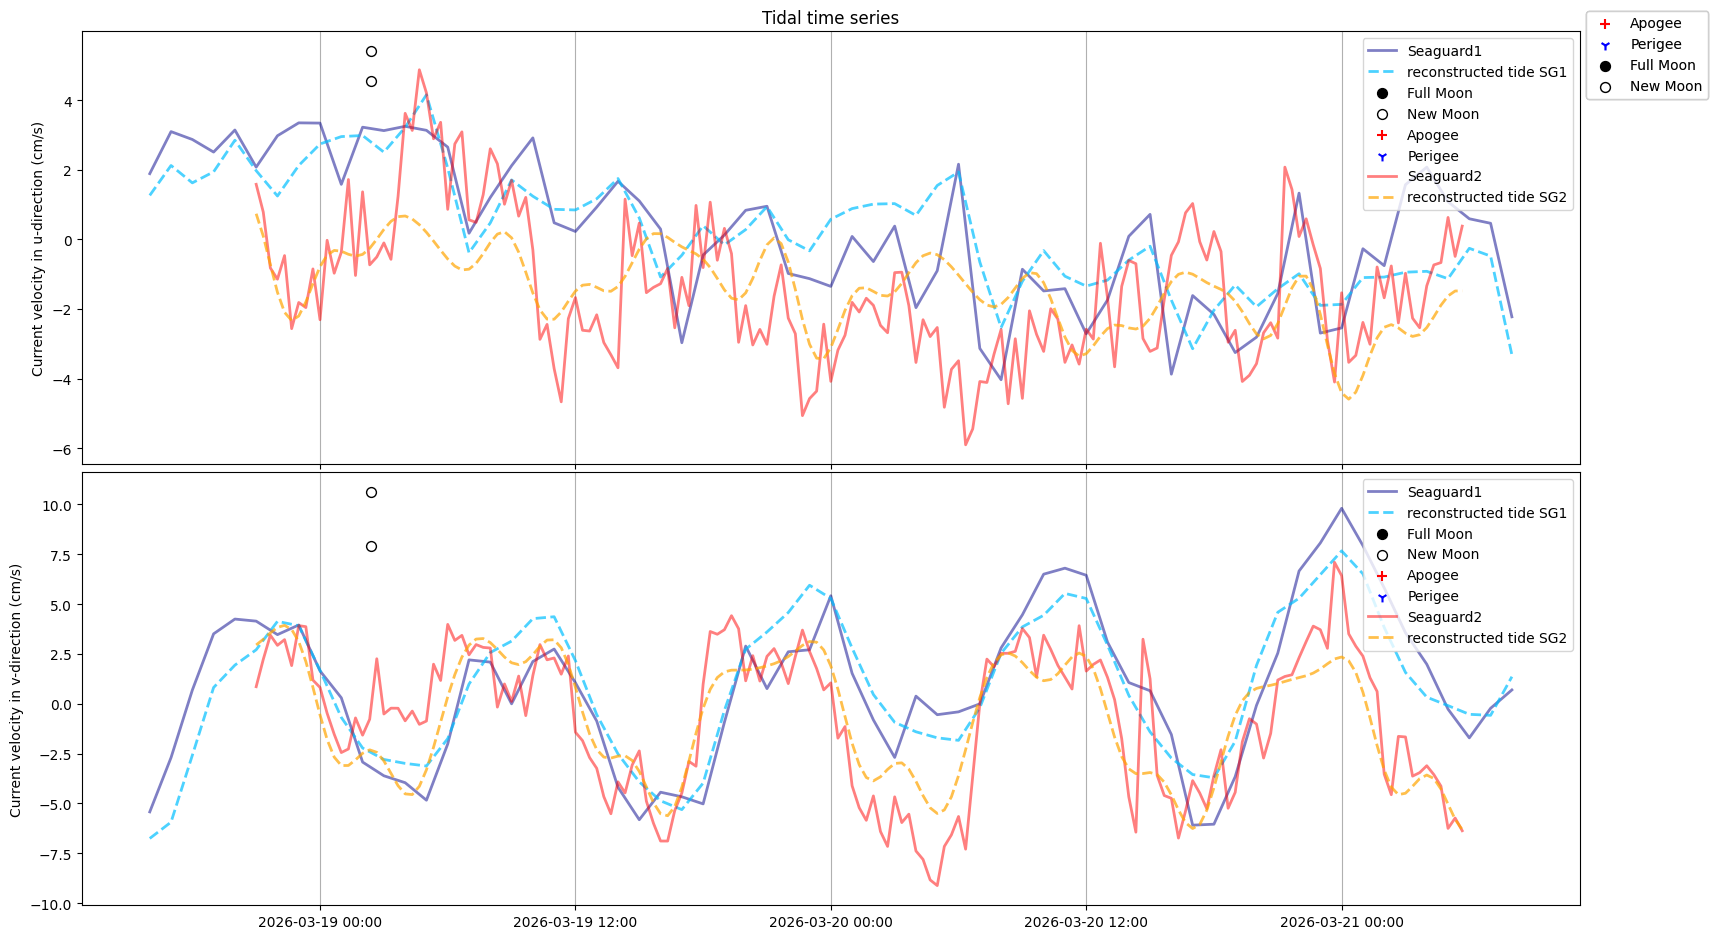

In [33]:
td.reconstruct(constituents=['M2', 'M6', 'K1', 'M3','2MK5','M8'])
td2.reconstruct(constituents=['M2', 'M6', 'M4', 'M8','2MK5', '3MK7'])
fig, axs=plt.subplots(2, 1, figsize=(16,10),sharex=True)
axs[0].set_title('Tidal time series')
axs[0].set_ylabel('Current velocity in u-direction (cm/s)')
axs[1].set_ylabel('Current velocity in v-direction (cm/s)')
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
Oc.plot_tidal_time_series(td.u,td.t, td.recon.u,transparent_labels="reconstructed tide SG1", fig=fig,ax=axs[0],
                          label= 'Seaguard1', data_args ={'color':'darkblue','linewidth':'2'},transparent_data_args={'color': 'deepskyblue', 'linestyle': '--', 'linewidth':'2'})
Oc.plot_tidal_time_series(td2.u,td2.t, td2.recon.u,transparent_labels="reconstructed tide SG2", fig=fig,ax=axs[0], label= 'Seaguard2', data_args ={'color':'red','linewidth':'2'},transparent_data_args={'color': 'orange', 'linestyle': '--','linewidth':'2'})
Oc.plot_tidal_time_series(td.v,td.t, td.recon.v,transparent_labels="reconstructed tide SG1", fig=fig,ax=axs[1], label= 'Seaguard1', data_args ={'color':'darkblue','linewidth':'2'},transparent_data_args={'color': 'deepskyblue', 'linestyle': '--','linewidth':'2'})
Oc.plot_tidal_time_series(td2.v,td2.t, td2.recon.v,transparent_labels="reconstructed tide SG2", fig=fig,ax=axs[1], label= 'Seaguard2', data_args ={'color':'red', 'linewidth':'2'},transparent_data_args={'color': 'orange', 'linestyle': '--','linewidth':'2'})
#fig.savefig('Tidal_plot.png')

In [36]:
td_dataframe=td.reconstruct(constituents=['M2', 'M6', 'K1', 'M3','2MK5','M8'])
#td_dataframe['tidal u']=td.u - td.recon.u_detide
#td_dataframe['tidal v']=td.v - td.recon.v_detide
#td_dataframe['tidal u_test']=SGuard1_data['u']
#td_dataframe['tidal v_test']=SGuard1_data['v']

td_dataframe['detrended tidal u']=signal.detrend(td_dataframe['u'])
td_dataframe['detrended tidal v']=signal.detrend(td_dataframe['v'])
td_dataframe['u_detide calc']=td.u-td_dataframe['detrended tidal u']
td_dataframe['v_detide calc']=td.v-td_dataframe['detrended tidal v']
td_dataframe

prep/calcs ... done.


,u,v,u_atide,v_atide,u_detide,v_detide,detrended tidal u,detrended tidal v,u_detide calc,v_detide calc
TIMESTAMP,,,,,,,,,,
2026-03-18 16:00:00,1.266364,-6.757485,1.060668,-7.631103,0.830332,2.206103,-1.247088,-5.933085,3.138088,0.508085
2026-03-18 17:00:00,2.126010,-5.937889,1.920314,-6.811506,1.179686,4.110506,-0.316956,-5.164134,3.416956,2.463134
2026-03-18 18:00:00,1.626743,-2.589011,1.421047,-3.462628,1.452953,4.146628,-0.745736,-1.865900,3.619736,2.549900
2026-03-18 19:00:00,1.943607,0.815181,1.737911,-0.058436,0.774089,3.566436,-0.358386,1.487646,2.870386,2.020354
2026-03-18 20:00:00,2.852550,1.937336,2.646854,1.063719,0.499146,3.185281,0.621043,2.559156,2.524957,1.689844
...,...,...,...,...,...,...,...,...,...,...
2026-03-21 04:00:00,-0.916941,0.331279,-1.122637,-0.542338,3.200637,2.527338,0.798777,-1.883044,1.279223,3.868044
2026-03-21 05:00:00,-1.128796,-0.094082,-1.334491,-0.967700,2.418491,0.695700,0.657408,-2.359051,0.426592,2.087051
2026-03-21 06:00:00,-0.255570,-0.530442,-0.461266,-1.404060,1.055266,-0.307940,1.601120,-2.846057,-1.007120,1.134057


In [37]:
td2_dataframe=td2.reconstruct(constituents=['M2', 'M6', 'M4', 'M8','2MK5', '3MK7']) 
#td2_dataframe['tidal u']=td2.u - td2.recon.u_detide
#td2_dataframe['tidal v']=td2.v - td2.recon.v_detide
td2_dataframe['detrended tidal u']=signal.detrend(td2_dataframe['u'])
td2_dataframe['detrended tidal v']=signal.detrend(td2_dataframe['v'])
td2_dataframe['u_detide calc']=td2.u-td2_dataframe['detrended tidal u']
td2_dataframe['v_detide calc']=td2.v-td2_dataframe['detrended tidal v']
td2_dataframe

prep/calcs ... done.


,u,v,u_atide,v_atide,u_detide,v_detide,detrended tidal u,detrended tidal v,u_detide calc,v_detide calc
TIMESTAMP,,,,,,,,,,
2026-03-18 21:00:00,0.738928,2.950293,2.146948,3.663453,-0.562194,-2.808285,1.011964,2.602361,0.572790,-1.747193
2026-03-18 21:20:00,0.095356,3.234246,1.503376,3.947406,-0.717196,-1.721724,0.382129,2.899451,0.404050,-0.673769
2026-03-18 21:40:00,-0.725141,3.555961,0.682879,4.269120,-1.502839,-0.827024,-0.424629,3.234304,-0.395331,0.207792
2026-03-18 22:00:00,-1.520481,3.831266,-0.112461,4.544426,-1.030992,-1.613577,-1.206231,3.522747,0.062778,-0.591898
2026-03-18 22:20:00,-2.096850,3.933266,-0.688830,4.646426,0.224694,-1.429432,-1.768862,3.637885,1.304726,-0.420891
...,...,...,...,...,...,...,...,...,...,...
2026-03-21 04:20:00,-2.223690,-3.747227,-0.815670,-3.034068,0.082619,-0.520570,0.329865,-1.914287,-1.062916,-1.640351
2026-03-21 04:40:00,-1.891576,-4.277976,-0.483556,-3.564816,-0.182005,-0.569096,0.675717,-2.431897,-1.341278,-1.702015
2026-03-21 05:00:00,-1.625183,-5.037758,-0.217163,-4.324598,0.849348,-1.929517,0.955848,-3.178541,-0.323663,-3.075574


-1.1188936802687571e-05


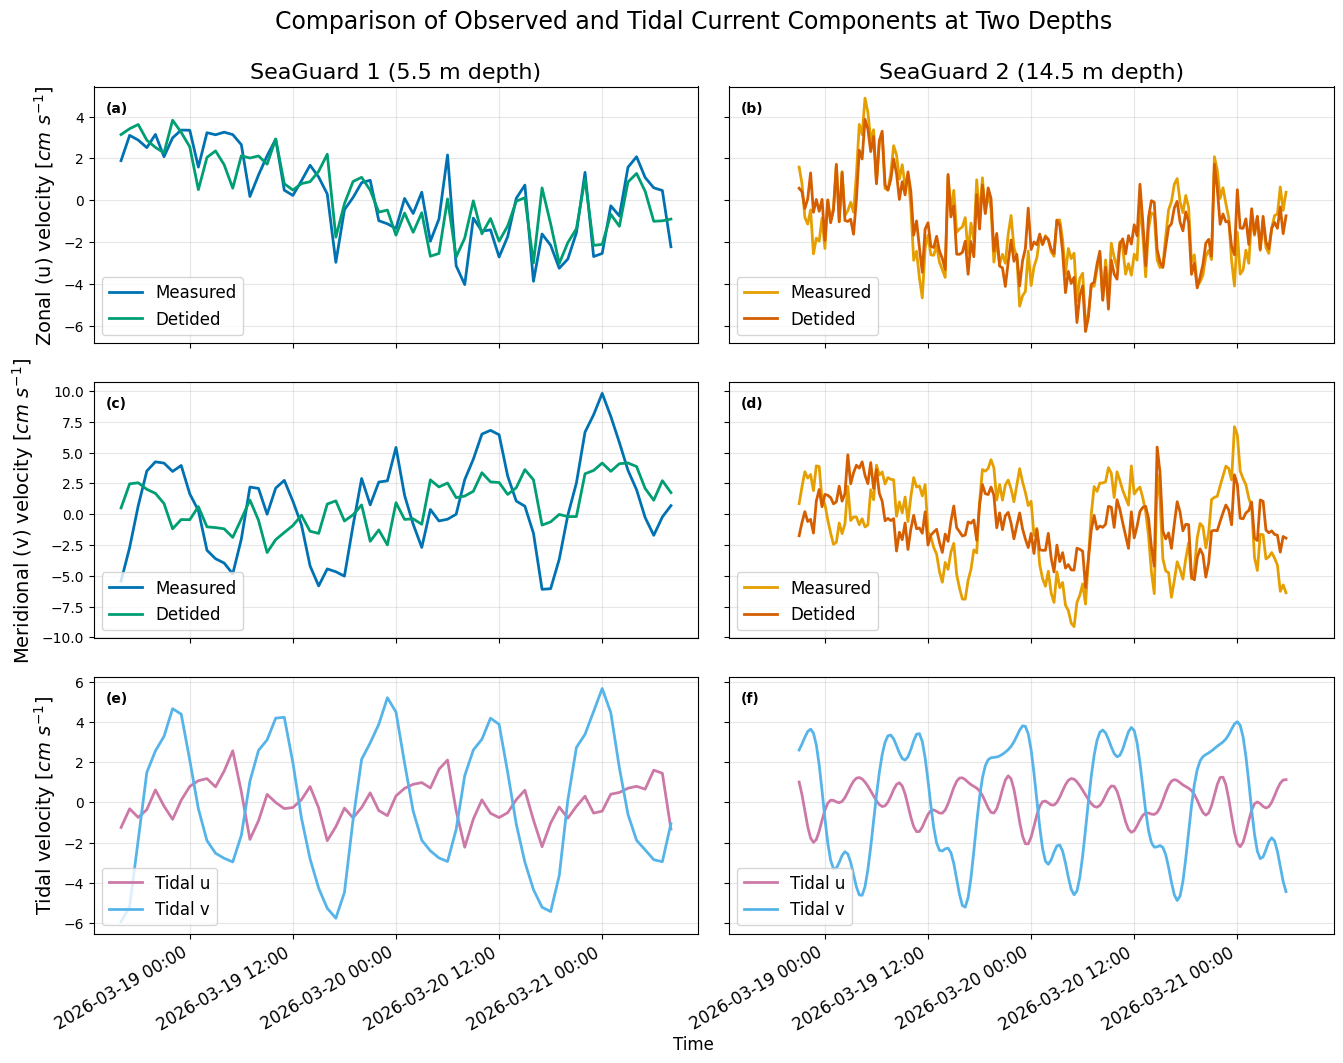

np.float64(-1.1188936802687571e-05)

In [54]:
import matplotlib.dates as mdates

from scipy import stats
time_numeric = (td2_dataframe.index - td2_dataframe.index[0]).total_seconds()

slope, intercept, r, p, std_err = stats.linregress(
    time_numeric,
    td2_dataframe['v_detide calc']
)

print(slope)

LABEL_FONTSIZE = 14
TICK_FONTSIZE = 12
LEGEND_FONTSIZE = 12
TITLE_FONTSIZE = 16

fig, axs = plt.subplots(3, 2, figsize=(16, 11), sharex=True, sharey='row')
#fig.set_constrained_layout_pads(wspace=0.01, hspace=0.05)
fig.subplots_adjust(wspace=0.05, hspace=0.15)
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
for ax, lab in zip(axs.flat, labels):
    ax.text(0.02, 0.9, lab, transform=ax.transAxes, fontweight='bold')
for ax in axs[:, 1]:
    ax.tick_params(labelleft=False)
# Add panel labels

# ===================== ROW 1: U velocity =====================
# ---- SG1 ----
axs[0, 0].set_title('SeaGuard 1 (5.5 m depth)', fontsize=TITLE_FONTSIZE)
axs[0, 0].plot(td.t, td['u'], label='Measured', color='#0072B2', lw=2)
#axs[0, 0].plot(td.t, td.recon.u_detide, label='Detided', color='#009E73', lw=2)
axs[0, 0].plot(td.t, td_dataframe['u_detide calc'], label='Detided', lw=2, color='#009E73')
axs[0, 0].set_ylabel(r'Zonal (u) velocity [$cm\ s^{-1}$]', fontsize=LABEL_FONTSIZE)
axs[0, 0].grid()
axs[0, 0].legend(loc='lower left', fontsize=LEGEND_FONTSIZE)

# ---- SG2 ----
axs[0, 1].set_title('SeaGuard 2 (14.5 m depth)', fontsize=TITLE_FONTSIZE)
axs[0, 1].plot(td2.t, td2['u'], label='Measured', color='#E69F00', lw=2)
#axs[0, 1].plot(td2.t, td2.recon.u_detide, label='Detided', color='#D55E00', lw=2)
axs[0, 1].plot(td2.t, td2_dataframe['u_detide calc'], label='Detided', lw=2, color='#D55E00')

axs[0, 1].grid()
axs[0, 1].legend(loc='lower left', fontsize=LEGEND_FONTSIZE)

# ===================== ROW 2: V velocity =====================
# ---- SG1 ----
axs[1, 0].plot(td.t, td['v'], label='Measured', color='#0072B2', lw=2)
#axs[1, 0].plot(td.t, td.recon.v_detide, label='Detided', color='#009E73', lw=2)
axs[1, 0].plot(td.t, td_dataframe['v_detide calc'], label='Detided', lw=2, color='#009E73')
#axs[1, 0].plot(SGuard1_data.index, SGuard1_data['v'], label='Measured_df', color='grey', lw=2)
axs[1, 0].set_ylabel(r'Meridional (v) velocity [$cm\ s^{-1}$]', fontsize=LABEL_FONTSIZE)
axs[1, 0].grid()
axs[1, 0].legend(loc='lower left', fontsize=LEGEND_FONTSIZE)

# ---- SG2 ----
axs[1, 1].plot(td2.t, td2['v'], label='Measured', color='#E69F00', lw=2)
#axs[1, 1].plot(td2.t, td2.recon.v_detide, label='Detided', color='#D55E00', lw=2)
axs[1, 1].plot(td2.t, td2_dataframe['v_detide calc'], label='Detided', lw=2, color='#D55E00')
axs[1, 1].grid()
axs[1, 1].legend(loc='lower left', fontsize=LEGEND_FONTSIZE)

# ===================== ROW 3: TIDAL (u & v) =====================
# ---- SG1 ----
#axs[2, 0].set_title('Eastward tidal velocity')
#axs[2, 0].plot(td.t, td.u - td.recon.u_detide, label='Tidal u', color='#CC79A7', lw=2)
#axs[2, 0].plot(td.t, td.v - td.recon.v_detide, label='Tidal v', color='#56B4E9', lw=4)
axs[2, 0].plot(td.t, td_dataframe['detrended tidal u'], label='Tidal u', color='#CC79A7', lw=2)
axs[2, 0].plot(td.t, td_dataframe['detrended tidal v'], label='Tidal v', color='#56B4E9', lw=2)
#axs[2, 0].plot(td_dataframe.index, td_dataframe['u'], label='u',color='black', lw=2, ls='--')
#axs[2, 0].plot(td_dataframe.index, td_dataframe['detrended tidal u'], label='detrend wild u tide', ls='--')
#axs[2, 0].plot(td_dataframe.index,td_dataframe['tidal u'], color='grey')
axs[2, 0].set_ylabel(r'Tidal velocity [$cm\ s^{-1}$]', fontsize=LABEL_FONTSIZE)
axs[2, 0].grid()
axs[2, 0].legend(loc='lower left', fontsize=LEGEND_FONTSIZE)

# ---- SG2 ----
#axs[2, 1].set_title('Northward tidal velocity')
#axs[2, 1].plot(td2.t, td2.u - td2.recon.u_detide, label='Tidal u', color='#CC79A7', lw=2)
#axs[2, 1].plot(td2.t, td2.v - td2.recon.v_detide, label='Tidal v', color='#56B4E9', lw=2)
axs[2, 1].plot(td2_dataframe.index, td2_dataframe['detrended tidal u'], label='Tidal u', color='#CC79A7', lw=2)
axs[2, 1].plot(td2_dataframe.index, td2_dataframe['detrended tidal v'], label='Tidal v', color='#56B4E9', lw=2)
#axs[2, 1].plot(td2.t, td2_dataframe['detrended tidal u'], label='detrend u tide')
#axs[2, 1].plot(td2_dataframe.index,td2_dataframe['tidal u'], color='grey')
#axs[2, 1].plot(crazy_idea.index, crazy_idea['v'] - crazy_idea['v_detide'], label='M6 Tidal v', color='grey', lw=1)

axs[2, 1].grid()
axs[2, 1].legend(loc='lower left', fontsize=LEGEND_FONTSIZE)

fig.text(0.5, 0.005, 'Time', ha='center', fontsize=12)

# ===================== X-axis formatting =====================
for ax in axs[-1, :]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    for label in ax.get_xticklabels():
        label.set_rotation(30)
        label.set_ha('right')
        label.set_fontsize(TICK_FONTSIZE)  # Ensure tick labels are readable
        
for ax in axs.flat:
    ax.grid(alpha=0.3)
#for i, ax in enumerate(axes):
#    ax.text(0.02, 0.98, f'({chr(97+i)})', transform=ax.transAxes,
#            fontsize=14, va='top', ha='left')
# ===================== Overall title =====================

fig.suptitle('Comparison of Observed and Tidal Current Components at Two Depths', fontsize=17, y=0.95)
#plt.savefig('Tidal_plots.png', dpi=300)
plt.show()
